# 📊 Sales Performance Analysis

## Project Overview

This project analyzes retail sales data to uncover patterns in sales performance, profitability, discounting, customer behavior, and geographical performance.

The goal is to transform raw retail transaction data into actionable business insights that can support better pricing, discount, product, and market strategies.

### Key Areas of Analysis

* Product category and sub-category performance
* Sales and profitability analysis
* Discount and profit relationships
* Regional performance
* Customer segment analysis
* State and city-level profitability
* Shipping mode performance
* Business insights and recommendations

### Objectives

By the end of this analysis, we aim to identify:

1. The products and categories driving the most revenue and profit.
2. The products and markets experiencing profitability challenges.
3. The relationship between discounting and profitability.
4. The best-performing regions, states, cities, and customer segments.
5. Data-driven recommendations for improving overall business performance.

### Tools Used

* Python
* Pandas
* Matplotlib
* Seaborn
* Jupyter Notebook

---

**Author:** Balogun Olamide Timothy
**Project:** Project Genesis — Project 2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

The Sample Superstore dataset is loaded into a Pandas DataFrame for analysis. The dataset contains information about customers, products, sales, discounts, profits, shipping methods, and geographical locations.


In [2]:
# Load the dataset
df = pd.read_csv("data/SampleSuperstore.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Initial Data Exploration

The dataset is inspected to understand its structure, dimensions, data types, and the variables available for analysis.


In [3]:
# Check the dataset dimensions
print("Dataset shape:", df.shape)

# Display the first 5 rows
df.head()

Dataset shape: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 3. Data Cleaning and Preparation

Before performing the analysis, the dataset was checked for missing values, duplicate records, data types, and basic statistical properties.

The cleaning process included:

* Checking for missing values.
* Identifying and removing duplicate records.
* Verifying the final dataset dimensions.
* Reviewing data types and descriptive statistics.
* Confirming that the dataset was ready for exploratory analysis.

In [4]:
# Check column names and data types
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB
None


### 3.1 Missing Value Analysis

The dataset was examined for missing values across all columns. This step ensures that missing data does not negatively affect the accuracy of subsequent analysis.


In [5]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


### 3.2 Duplicate Record Analysis

Duplicate records were identified to ensure that repeated transactions did not distort sales, profit, or other statistical calculations.


In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 17


In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows removed successfully!")
print("New dataset shape:", df.shape)

Duplicate rows removed successfully!
New dataset shape: (9977, 13)


### 3.3 Descriptive Statistics

Descriptive statistics were generated for the numerical variables to understand the central tendency, spread, and range of the dataset.


In [8]:
# Generate descriptive statistics for numerical columns
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to identify patterns, trends, relationships, and potential business insights within the sales dataset.

The analysis focuses on sales, profitability, discounts, products, customers, shipping methods, and geographical performance.


In [9]:
# Check the number of unique values in each column
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

### 4.1 Sales Distribution

The distribution of sales values was examined to understand the spread of order values and identify potential patterns or extreme observations within the dataset.


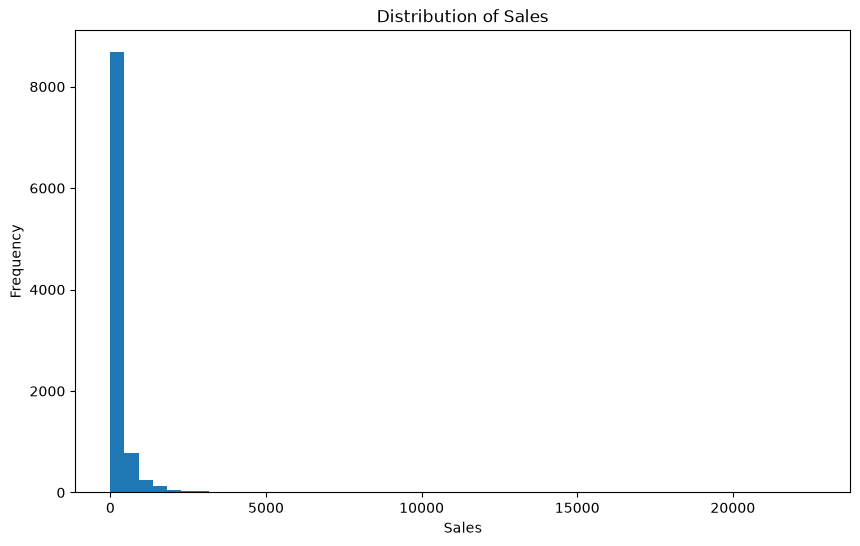

In [10]:
# Plot the distribution of sales
plt.figure(figsize=(10, 6))

plt.hist(df["Sales"], bins=50)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

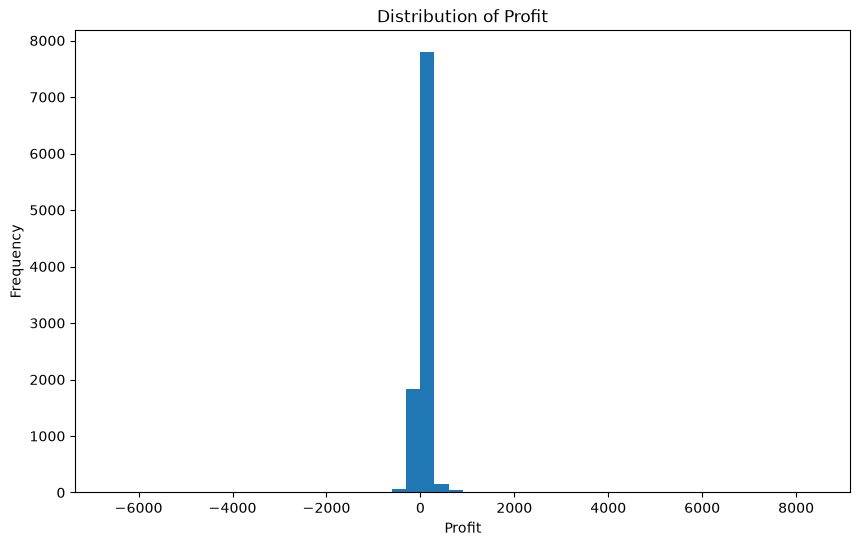

In [11]:
# Plot the distribution of profit
plt.figure(figsize=(10, 6))

plt.hist(df["Profit"], bins=50)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

### 4.2 Sales and Profit by Product Category

Sales and profit were analyzed across the three main product categories to identify which categories contribute most to revenue and overall profitability.

This analysis helps the business understand the performance of each product category and identify areas with strong profitability as well as categories that may require improvement.

The analysis also considers profit margins to provide a better understanding of profitability relative to sales.


In [12]:
# Calculate total sales and profit by product category
category_performance = df.groupby("Category")[["Sales", "Profit"]].sum()

print(category_performance)

                       Sales       Profit
Category                                 
Furniture        741306.3133   18421.8137
Office Supplies  718735.2440  122364.6608
Technology       836154.0330  145454.9481


In [13]:
# Calculate profit margin by category
category_performance["Profit Margin (%)"] = (
    category_performance["Profit"] / category_performance["Sales"]
) * 100

print(category_performance)

                       Sales       Profit  Profit Margin (%)
Category                                                    
Furniture        741306.3133   18421.8137           2.485047
Office Supplies  718735.2440  122364.6608          17.024998
Technology       836154.0330  145454.9481          17.395712


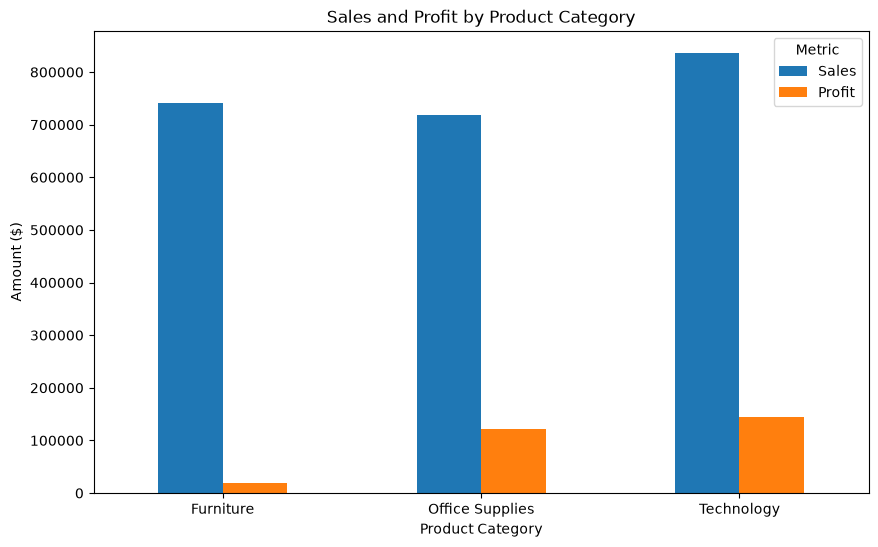

In [14]:
# Visualize sales and profit by category

category_performance[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

### 4.3 Sales and Profit by Product Sub-Category

Sales and profit were analyzed across individual product sub-categories to identify the products that contribute most to revenue and profitability and those that may require further attention.

This analysis helps identify high-performing products as well as loss-making sub-categories that could benefit from pricing, cost, or discount strategy adjustments.


In [15]:
# Analyze sales and profit by sub-category
subcategory_performance = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

# Sort by profit from highest to lowest
subcategory_performance = subcategory_performance.sort_values(
    by="Profit",
    ascending=False
)

print(subcategory_performance)

                    Sales      Profit
Sub-Category                         
Copiers       149528.0300  55617.8249
Phones        330007.0540  44515.7306
Accessories   167380.3180  41936.6357
Paper          78224.1420  33944.2395
Binders       203409.1690  30228.0003
Chairs        327777.7610  26567.1278
Storage       223843.6080  21278.8264
Appliances    107532.1610  18138.0054
Furnishings    91683.0240  13052.7230
Envelopes      16476.4020   6964.1767
Art            27107.0320   6524.6118
Labels         12444.9120   5526.3820
Machines      189238.6310   3384.7569
Fasteners       3024.2800    949.5182
Supplies       46673.5380  -1189.0995
Bookcases     114879.9963  -3472.5560
Tables        206965.5320 -17725.4811


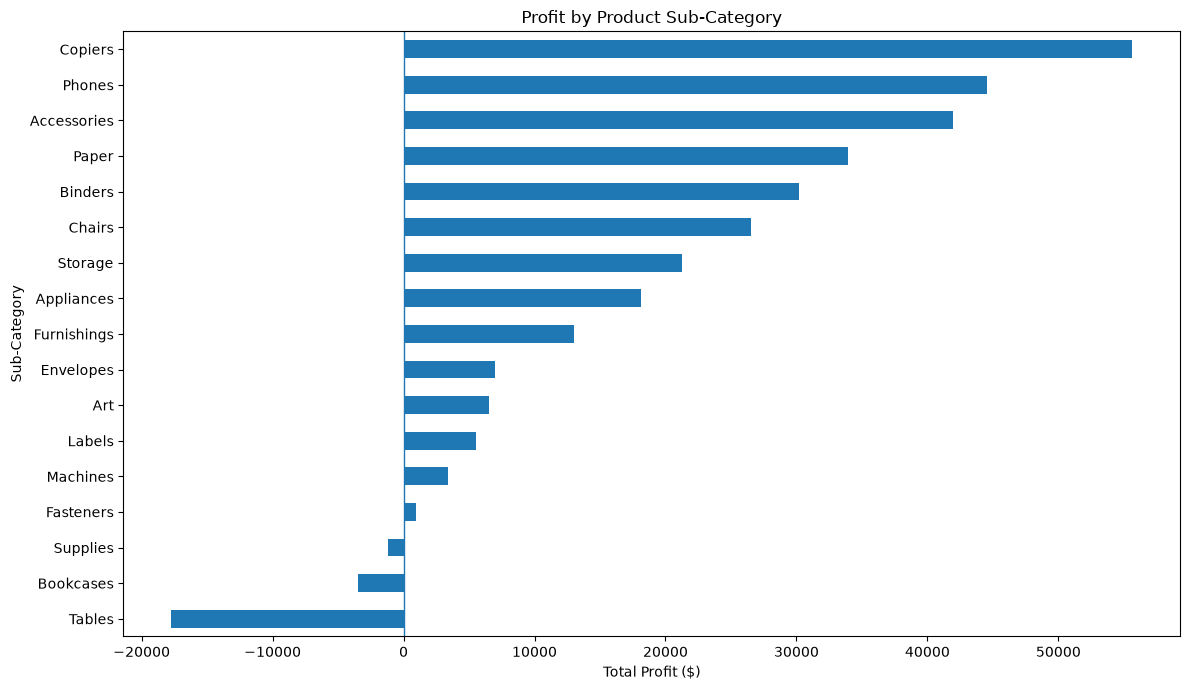

In [16]:
# Visualize profit by sub-category

plt.figure(figsize=(12, 7))

subcategory_performance["Profit"].sort_values().plot(
    kind="barh"
)

plt.title("Profit by Product Sub-Category")
plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### 4.4 Discount and Profit Analysis

The relationship between discount levels and profitability was analyzed to determine how pricing discounts affect business performance.

The analysis compares different discount levels with their corresponding average and total profit.

The results indicate that higher discount levels are generally associated with lower profitability. Discounts of 30% or more frequently result in negative average profits, suggesting that excessive discounting may significantly reduce profitability.

This analysis provides insight into the importance of developing a data-driven discount strategy that balances customer incentives with sustainable profit margins.


In [17]:
# Analyze average profit by discount level
discount_analysis = df.groupby("Discount")["Profit"].agg(
    ["mean", "sum", "count"]
)

print(discount_analysis)

                mean          sum  count
Discount                                
0.00       67.024108  320844.4073   4787
0.10       96.055074    9029.1770     94
0.15       27.288298    1418.9915     52
0.20       24.721217   90306.6070   3653
0.30      -45.828401  -10357.2186    226
0.32      -88.560656   -2391.1377     27
0.40     -111.927429  -23057.0504    206
0.45     -226.646464   -2493.1111     11
0.50     -310.703456  -20506.4281     66
0.60      -43.077212   -5944.6552    138
0.70      -95.874060  -40075.3569    418
0.80     -102.116395  -30532.8022    299


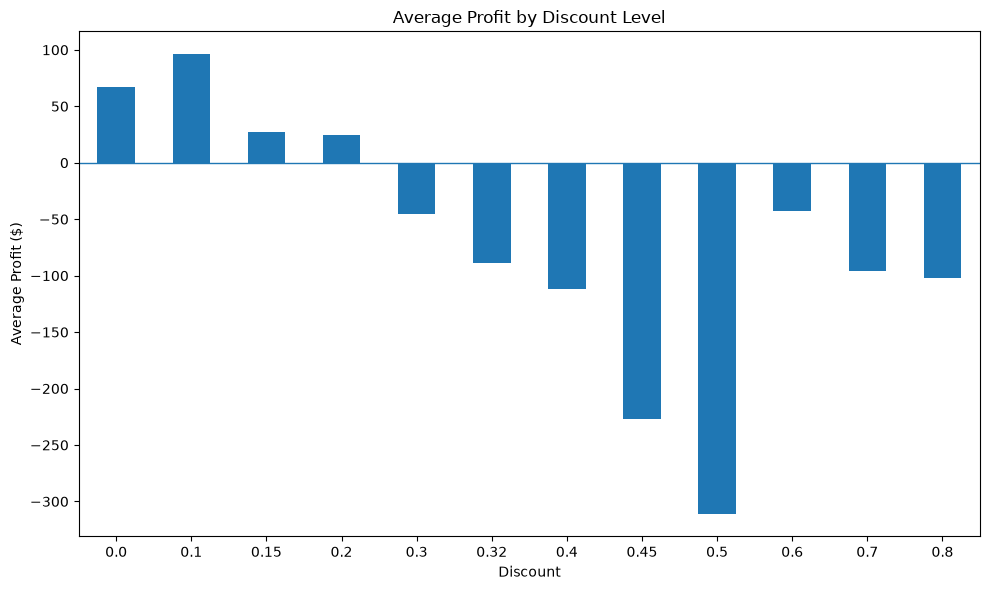

In [18]:
# Visualize the relationship between discount and average profit

plt.figure(figsize=(10, 6))

discount_analysis["mean"].plot(
    kind="bar"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")
plt.axhline(0, linewidth=1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.5 Discount and Profit by Product Category

The relationship between discount levels and profitability was further examined across product categories.

The analysis compares the average discount applied to each category with its corresponding average profit to identify whether differences in discounting may be associated with differences in profitability.

The results show that Furniture has the highest average discount and the lowest average profit among the three categories. In contrast, Technology has the lowest average discount and the highest average profit.

This suggests that excessive discounting may contribute to lower profitability, particularly within the Furniture category.


In [19]:
# Analyze average discount and profit by category

category_discount_analysis = df.groupby("Category")[["Discount", "Profit"]].mean()

print(category_discount_analysis)

                 Discount     Profit
Category                            
Furniture        0.174027   8.697740
Office Supplies  0.157385  20.353403
Technology       0.132323  78.752002


### 4.6 Discount and Profit by Product Sub-Category

The relationship between discount levels and profitability was examined at the product sub-category level to identify products that may be affected by aggressive discounting.

The analysis compares the average discount applied to each sub-category with its corresponding average profit.

The results show that some sub-categories, such as **Tables** and **Bookcases**, have relatively high average discounts and negative average profits. In contrast, sub-categories such as **Copiers**, **Phones**, and **Accessories** demonstrate stronger profitability.

These findings suggest that discount strategies should be tailored to individual products and sub-categories rather than applying a uniform discount policy across the entire business.


In [20]:
# Analyze average discount and profit by sub-category

subcategory_discount_analysis = df.groupby("Sub-Category")[["Discount", "Profit"]].mean()

# Sort by average discount
subcategory_discount_analysis = subcategory_discount_analysis.sort_values(
    by="Discount",
    ascending=False
)

print(subcategory_discount_analysis)

              Discount      Profit
Sub-Category                      
Binders       0.372011   19.860710
Machines      0.306087   29.432669
Tables        0.261285  -55.565771
Bookcases     0.211140  -15.230509
Chairs        0.170244   43.198582
Appliances    0.166524   38.922758
Copiers       0.161765  817.909190
Phones        0.154556   50.073938
Furnishings   0.138494   13.653476
Fasteners     0.082028    4.375660
Envelopes     0.080315   27.418019
Accessories   0.078452   54.111788
Supplies      0.076842   -6.258418
Art           0.074969    8.207059
Paper         0.074908   24.977365
Storage       0.074704   25.152277
Labels        0.068871   15.224193


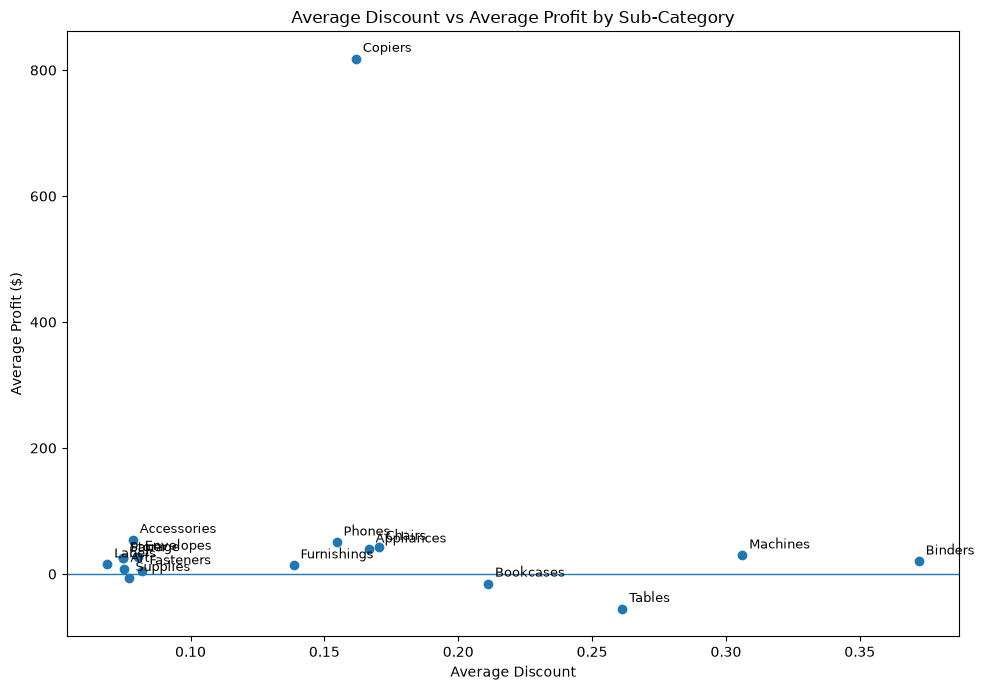

In [21]:
# Visualize discount vs average profit by sub-category

plt.figure(figsize=(10, 7))

plt.scatter(
    subcategory_discount_analysis["Discount"],
    subcategory_discount_analysis["Profit"]
)

# Add sub-category labels
for subcategory, row in subcategory_discount_analysis.iterrows():
    plt.annotate(
        subcategory,
        (row["Discount"], row["Profit"]),
        fontsize=9,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.title("Average Discount vs Average Profit by Sub-Category")
plt.xlabel("Average Discount")
plt.ylabel("Average Profit ($)")

plt.tight_layout()
plt.show()

### 4.7 Regional Performance Analysis

Sales and profitability were analyzed across the four geographic regions to identify the strongest and weakest-performing markets.

The West region recorded the highest total sales and profit, making it the strongest-performing region in the dataset. The South region recorded the lowest sales, while the Central region showed relatively lower profitability compared with its sales volume.

These findings highlight the importance of understanding regional differences in product demand, pricing, discounting, and profitability when developing business strategies.


In [22]:
# Analyze sales and profit by region

region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

print(region_analysis)

               Sales       Profit
Region                           
Central  500782.8528   39655.8752
East     678435.1960   91506.3092
South    391721.9050   46749.4303
West     725255.6365  108329.8079


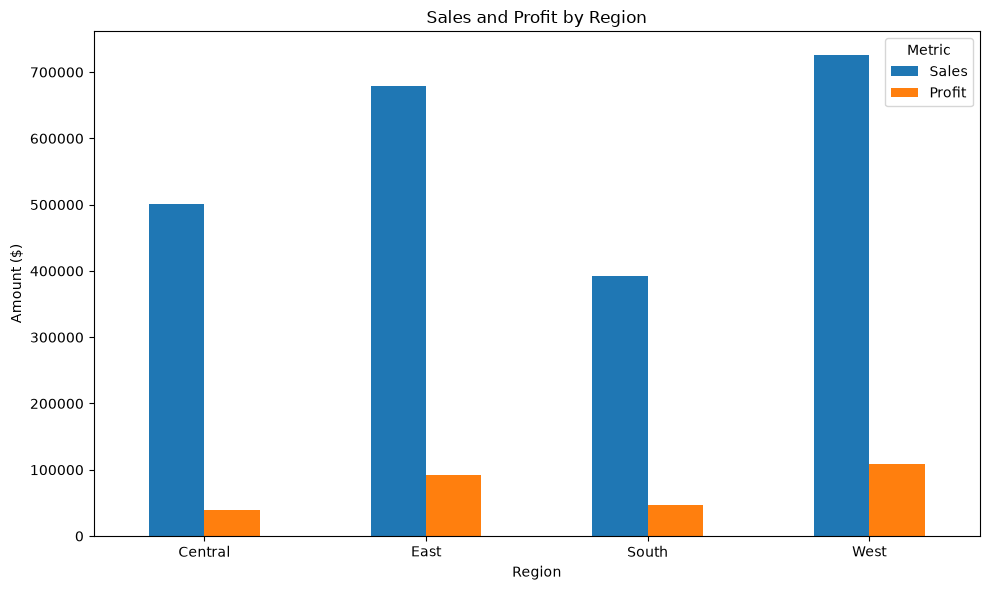

In [23]:
# Visualize sales and profit by region

region_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### 4.8 Customer Segment Analysis

Sales and profitability were analyzed across the three customer segments: Consumer, Corporate, and Home Office.

The Consumer segment generated the highest total sales and profit, making it the largest contributor to overall revenue. However, the Home Office segment recorded the highest profit margin, indicating stronger profitability relative to its sales volume.

These findings suggest that the business should continue to focus on the Consumer segment while exploring opportunities to grow the Home Office segment and maintain its stronger profit margin.


In [24]:
# Analyze sales and profit by customer segment

segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()

# Calculate profit margin
segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
) * 100

print(segment_analysis)

                    Sales       Profit  Profit Margin (%)
Segment                                                  
Consumer     1.160833e+06  134007.4413          11.544078
Corporate    7.060701e+05   91954.9798          13.023491
Home Office  4.292927e+05   60279.0015          14.041470


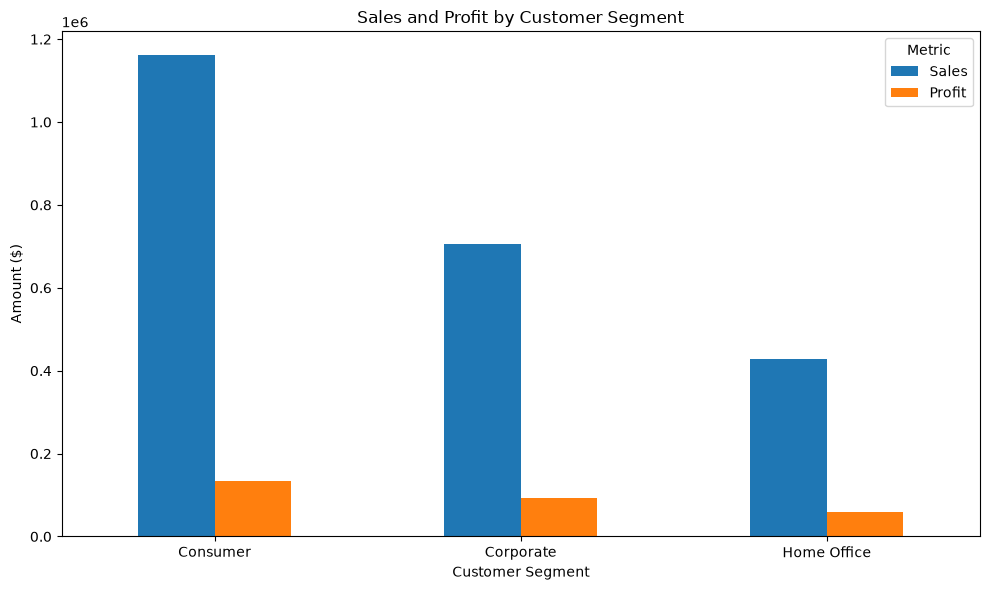

In [25]:
# Visualize sales and profit by customer segment

segment_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

In [26]:
# Analyze sales and profit by customer segment

segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()

# Calculate profit margin
segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
) * 100

print(segment_analysis)

                    Sales       Profit  Profit Margin (%)
Segment                                                  
Consumer     1.160833e+06  134007.4413          11.544078
Corporate    7.060701e+05   91954.9798          13.023491
Home Office  4.292927e+05   60279.0015          14.041470


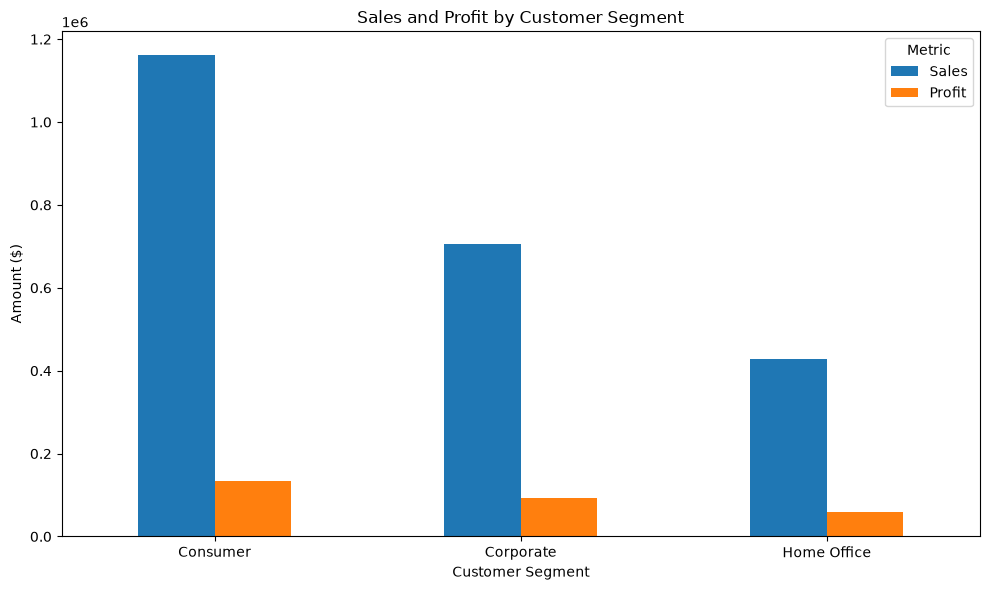

In [27]:
# Visualize sales and profit by customer segment

segment_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### 4.9 Shipping Mode Analysis

Sales, profitability, and profit margins were analyzed across the different shipping modes to understand how shipping methods relate to business performance.

Standard Class generated the highest total sales and profit due to its high order volume. However, First Class recorded the highest profit margin, indicating stronger profitability relative to its sales volume.

These findings suggest that shipping performance should be evaluated not only by sales volume but also by profitability and the potential relationship between shipping methods, order value, and associated costs.


In [28]:
# Analyze sales and profit by ship mode

ship_mode_analysis = df.groupby("Ship Mode")[["Sales", "Profit"]].sum()

# Calculate profit margin
ship_mode_analysis["Profit Margin (%)"] = (
    ship_mode_analysis["Profit"] / ship_mode_analysis["Sales"] * 100
)

print(ship_mode_analysis)

                       Sales       Profit  Profit Margin (%)
Ship Mode                                                   
First Class     3.513805e+05   48953.6561          13.931809
Same Day        1.283217e+05   15871.8869          12.368823
Second Class    4.591770e+05   57446.6516          12.510785
Standard Class  1.357316e+06  163969.2280          12.080399


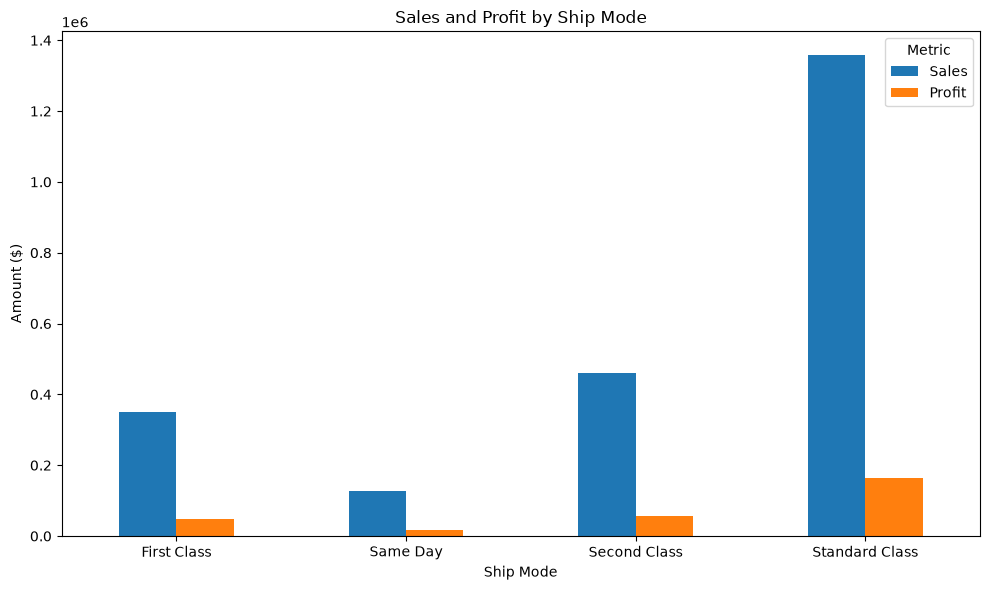

In [29]:
# Visualize sales and profit by ship mode

ship_mode_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### 4.10 City-Level Analysis

Sales and profitability were analyzed at the city level to identify major markets and locations that may require further investigation.

New York City recorded the highest sales and profit among the cities analyzed, making it a major contributor to overall business performance. However, some cities with significant sales volumes, including Philadelphia, Houston, and Chicago, recorded negative profits.

These findings demonstrate that high sales volume does not necessarily guarantee profitability. The business should investigate the underlying factors affecting profitability in loss-making cities, including product mix, discount levels, pricing strategies, and operating costs.


In [30]:
# Analyze sales and profit by city

city_analysis = (
    df.groupby("City")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

# Display the top 10 cities by sales
top_10_cities = city_analysis.head(10)

print(top_10_cities)

                     Sales      Profit
City                                  
New York City  256319.0410  62013.8973
Los Angeles    175831.9010  30431.4267
Seattle        119460.2820  29121.6825
San Francisco  112577.1720  17466.1186
Philadelphia   109061.4610 -13843.2106
Houston         64441.2564 -10175.1755
Chicago         48535.9770  -6648.3318
San Diego       47521.0290   6377.1960
Jacksonville    44713.1830  -2323.8350
Springfield     43054.3420   6200.6974


### 4.11 State-Level Profitability Analysis

Profitability was analyzed across U.S. states to identify the strongest and weakest-performing geographic markets.

California and New York recorded the highest total profits among the states analyzed, while Texas recorded the largest loss. Other states with significant negative profits included Ohio, Pennsylvania, and Illinois.

These findings demonstrate significant geographic variation in profitability. The company should investigate the factors contributing to losses in underperforming states, including product mix, discount levels, pricing strategies, and operational costs.

Understanding state-level performance can help management develop targeted strategies for improving profitability in weaker markets while maintaining growth in high-performing states.


In [31]:
# Analyze profit by state

state_profit = df.groupby("State")["Profit"].sum().sort_values(ascending=False)

# Top 10 most profitable states
top_10_states = state_profit.head(10)

# Bottom 10 least profitable states
bottom_10_states = state_profit.tail(10)

print("Top 10 Most Profitable States:")
print(top_10_states)

print("\n10 Least Profitable States:")
print(bottom_10_states)

Top 10 Most Profitable States:
State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

10 Least Profitable States:
State
Oregon            -1194.0993
Florida           -3399.3017
Arizona           -3427.9246
Tennessee         -5341.6936
Colorado          -6527.8579
North Carolina    -7490.9122
Illinois         -12601.6500
Pennsylvania     -15565.4035
Ohio             -16959.3178
Texas            -25750.9833
Name: Profit, dtype: float64


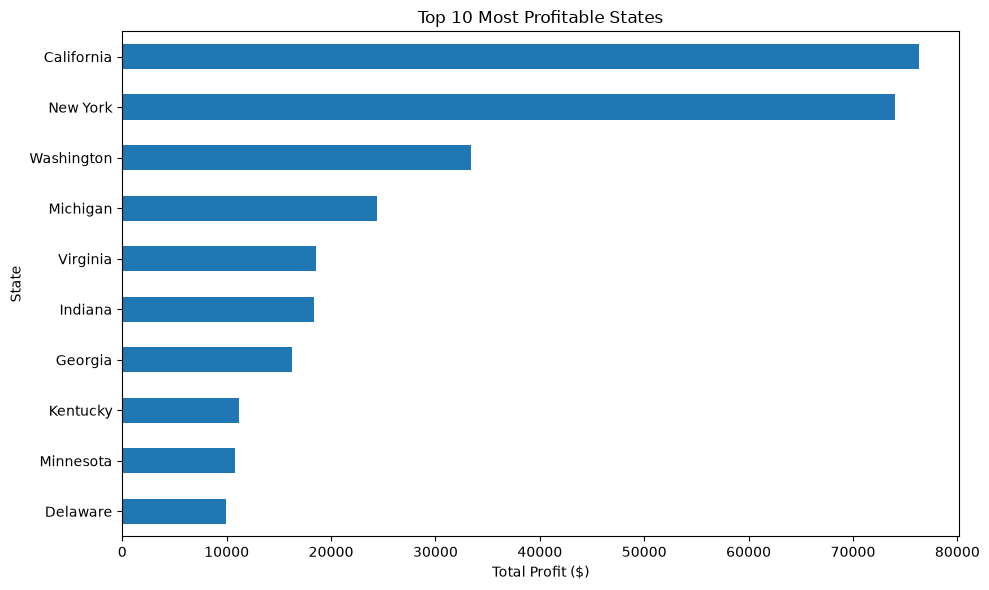

In [32]:
# Visualize the top 10 most profitable states

top_10_states.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Most Profitable States")
plt.xlabel("Total Profit ($)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

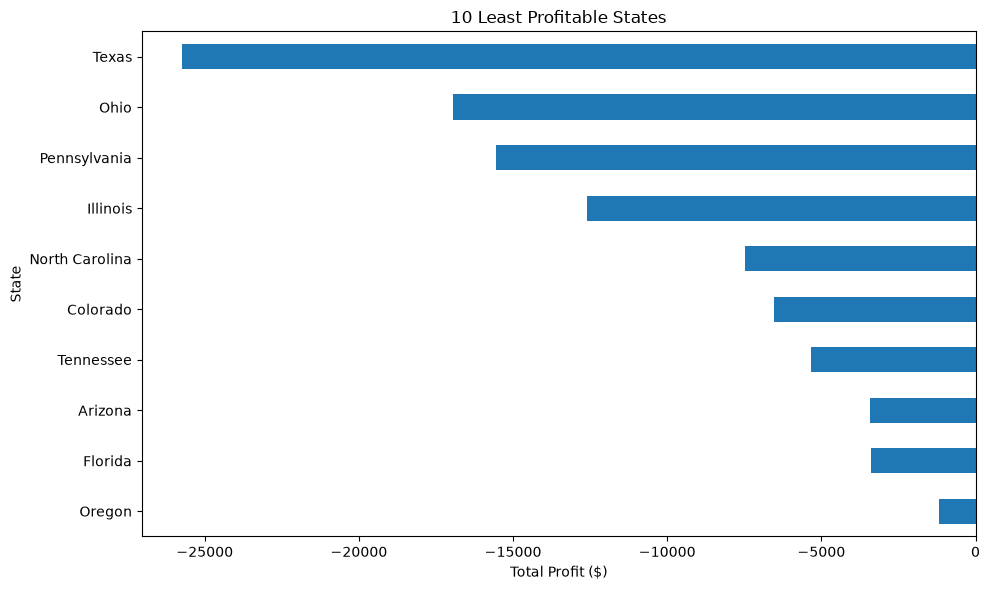

In [33]:
# Visualize the 10 least profitable states

bottom_10_states.sort_values(ascending=False).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("10 Least Profitable States")
plt.xlabel("Total Profit ($)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

# Key Insights and Business Recommendations

## Key Insights

Based on the analysis of the sales performance dataset, several important business insights were identified:

### 1. Technology is the most profitable product category

Technology generated the highest total sales of approximately **$836,154** and the highest profit margin of approximately **17.4%**. This indicates that the Technology category is a strong contributor to overall business performance.

**Recommendation:** The business should consider expanding its Technology product offerings and investing more resources in high-performing products within this category.

### 2. Furniture has a profitability problem

Although Furniture generated approximately **$741,306 in sales**, its profit was only about **$18,422**, resulting in a very low profit margin of approximately **2.5%**.

**Recommendation:** The company should review the pricing, discount levels, and costs associated with Furniture products. Particular attention should be given to loss-making sub-categories such as **Tables** and **Bookcases**.

### 3. High discounts are associated with lower profitability

The analysis shows that average profit decreases significantly as discount levels increase. Discounts of **30% or more** are generally associated with negative average profit.

**Recommendation:** The company should reduce excessive discounting and establish discount limits based on product profitability. Discounts should be strategically applied rather than used broadly across products.

### 4. Some product sub-categories require immediate attention

**Tables** and **Bookcases** recorded negative total profits, with Tables being the largest loss-making sub-category. **Supplies** also recorded a negative total profit.

**Recommendation:** Management should investigate the pricing, costs, and discount strategies for these products. The company should consider renegotiating supplier costs, adjusting prices, or reducing discounts on consistently loss-making products.

### 5. The West region is the strongest-performing region

The West region recorded the highest sales of approximately **$725,256** and the highest profit of approximately **$108,330**.

**Recommendation:** The company should study the factors contributing to the West region's strong performance and consider applying successful strategies to weaker regions.

### 6. The South region has the lowest sales

The South region generated approximately **$391,722** in sales, making it the lowest-performing region by sales.

**Recommendation:** The business should investigate customer demand, product mix, pricing, and marketing strategies in the South region to identify opportunities for growth.

### 7. Consumer is the largest customer segment

The Consumer segment generated the highest sales of approximately **$1.16 million** and the highest total profit of approximately **$134,007**.

However, the Home Office segment recorded the highest profit margin at approximately **14.0%**, compared with approximately **11.5%** for Consumer.

**Recommendation:** The company should continue serving the Consumer segment while developing targeted strategies to increase sales from the more profitable Home Office segment.

### 8. Profitability varies significantly across states

California and New York were the most profitable states, while Texas recorded the largest loss at approximately **-$25,751**.

**Recommendation:** The company should investigate the reasons for poor profitability in Texas and other loss-making states. Factors such as high discounts, product mix, shipping costs, and pricing should be examined.

### 9. Some major cities generate significant losses

While New York City was the most profitable city among the cities analyzed, cities such as **Philadelphia, Houston, and Chicago** recorded negative profits.

**Recommendation:** The company should conduct city-level analysis to determine whether specific products, discount policies, or operating costs are responsible for these losses.

### 10. Shipping mode has limited impact on overall profitability

Standard Class generated the highest sales and total profit because of its large sales volume. However, its profit margin was lower than First Class.

**Recommendation:** The company should evaluate whether customers using faster shipping methods generate higher-value orders and determine whether shipping costs are affecting profitability.

---

# Business Recommendations

Based on the findings, the following actions are recommended:

1. **Reduce excessive discounts**, especially discounts of 30% or higher, unless they are part of a carefully planned promotional strategy.

2. **Review loss-making products**, particularly Tables, Bookcases, and Supplies, and consider adjusting prices, reducing costs, or changing discount policies.

3. **Invest more in high-performing categories**, especially Technology and profitable Technology sub-categories such as Copiers and Phones.

4. **Improve Furniture profitability** by reviewing product pricing, supplier costs, and discount strategies.

5. **Investigate underperforming regions and states**, particularly the South region and loss-making states such as Texas, Ohio, and Pennsylvania.

6. **Expand strategies that work in high-performing markets**, particularly the West region and highly profitable states such as California and New York.

7. **Increase focus on high-margin customer segments**, especially Home Office customers, while maintaining the Consumer segment as the largest revenue contributor.

8. **Use data-driven discount strategies** by considering product category, sub-category, region, and customer segment before offering discounts.

9. **Monitor profitability at the city level** to identify locations where sales volume is high but profitability is poor.

10. **Develop a continuous sales and profit monitoring system** using dashboards or regular reports to track changes in sales, profit, discounts, and margins over time.

# Conclusion

The analysis demonstrates that strong sales performance does not always translate into strong profitability. While the business generates substantial revenue from Technology products and the Consumer segment, certain product categories, sub-categories, regions, and states experience significant profitability challenges.

The most important finding is the relationship between **discounting and profitability**. Higher discount levels are generally associated with lower or negative profits. Therefore, improving discount management, reviewing loss-making products, and focusing on high-margin categories and markets could significantly improve overall business performance.

Overall, the company should adopt a more **profit-focused and data-driven strategy** rather than focusing solely on increasing sales. By combining effective pricing, controlled discounting, product optimization, and targeted regional strategies, the business can improve profitability while maintaining sustainable sales growth.
